In [2]:
import numpy as np
import matplotlib.pyplot as plt

def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [3]:
#fake data: 20 points roughly tracing Svalbard -> Antarctica -> Svalbard
#day index 0-364, made-up lat/lon to mimic a full year's migration
days = np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 140,
                  160, 180, 210, 240, 260, 280, 300, 320, 340, 364])

lats = np.array([78, 70, 55, 40, 20, 5, -10, -25, -40, -55,
                  -65, -60, -45, -25, -5, 20, 40, 60, 72, 78])

lons = np.array([15, 10, 5, 0, -10, -20, -25, -20, -15, -10,
                  0, 10, 15, 10, 5, 0, -5, 0, 10, 15])


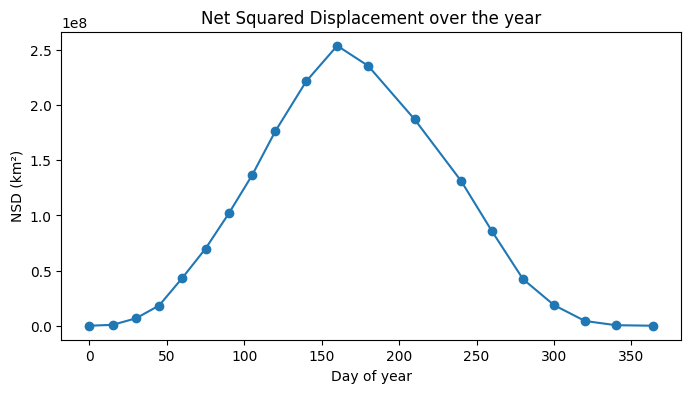

In [4]:
home_lat, home_lon = lats[0], lons[0]

distances = haversine(home_lat, home_lon, lats, lons)
nsd = distances ** 2  # "net squared displacement"

plt.figure(figsize=(8,4))
plt.plot(days, nsd, marker='o')
plt.xlabel("Day of year")
plt.ylabel("NSD (km²)")
plt.title("Net Squared Displacement over the year")
plt.show()

Peak NSD at day 160 (index 10)


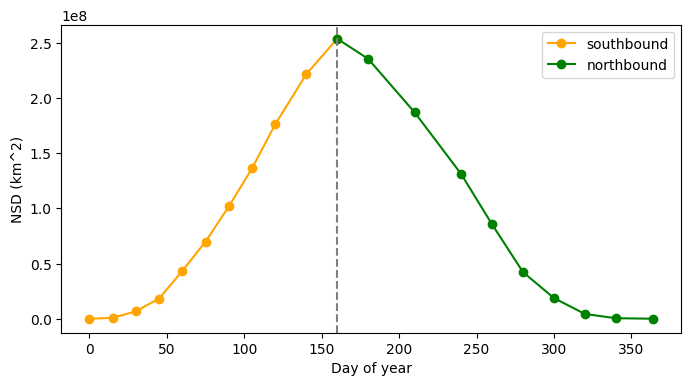

In [6]:
#Cell 4 — find the peak and label north/southbound
peak_idx = np.argmax(nsd)
print(f"Peak NSD at day {days[peak_idx]} (index {peak_idx})")

southbound = days <= days[peak_idx]
northbound = days >= days[peak_idx]

plt.figure(figsize=(8,4))
plt.plot(days[southbound], nsd[southbound], 'o-', color='orange', label='southbound')
plt.plot(days[northbound], nsd[northbound], 'o-', color='green', label='northbound')
plt.axvline(days[peak_idx], linestyle='--', color='gray')
plt.legend()
plt.xlabel("Day of year")
plt.ylabel("NSD (km^2)")
plt.show()